Model Training

Import Data and Required Packages

In [21]:
# Basic Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#modelling
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [4]:
#Load the data
df = pd.read_csv(r'C:\Users\selvam.anandhan\OneDrive - IDP Education Ltd\Documents\DS\myproject\artifact\Mall_Customers.csv')

#We will use Annual Income and Spending Score for Clustering
X = df.iloc[:,[3,4]].values

In [7]:
# 2. Scale Data (Crucial for K-Means)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
X_scaled.shape

(200, 2)

3. Find Optimal K (Elbow Method)

In [11]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

c:\Users\selvam.anandhan\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\selvam.anandhan\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")
c:\Users\selvam.anandhan\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\selvam.anandhan\AppData\Local\anaconda3\Lib\site-packages\sklearn\clu

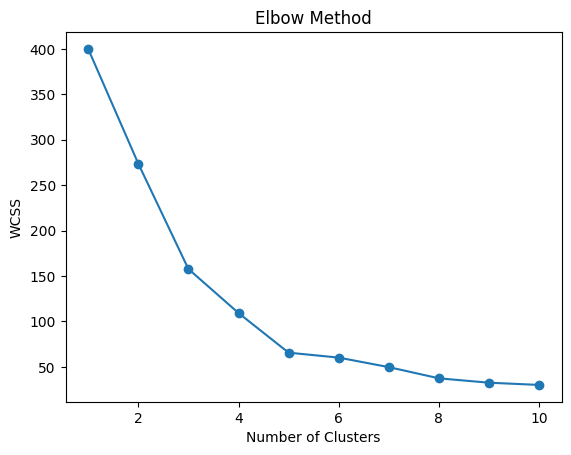

In [15]:
#Plot

plt.plot(range(1,11),wcss,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

Create an Evaluate Function to give all metrics after model training


In [16]:
# 4. Train the Final Model
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)

Prediction

In [17]:
y_kmeans = kmeans.fit_predict(X_scaled)

c:\Users\selvam.anandhan\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


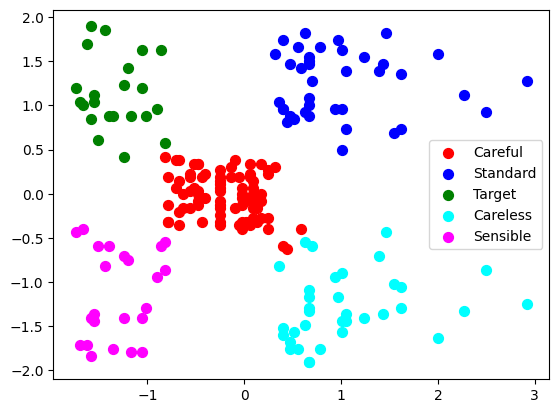

In [18]:
# 5. Visualize the Segments
plt.scatter(X_scaled[y_kmeans == 0, 0], X_scaled[y_kmeans == 0, 1], s=50, c='red', label='Careful')
plt.scatter(X_scaled[y_kmeans == 1, 0], X_scaled[y_kmeans == 1, 1], s=50, c='blue', label='Standard')
plt.scatter(X_scaled[y_kmeans == 2, 0], X_scaled[y_kmeans == 2, 1], s=50, c='green', label='Target')
plt.scatter(X_scaled[y_kmeans == 3, 0], X_scaled[y_kmeans == 3, 1], s=50, c='cyan', label='Careless')
plt.scatter(X_scaled[y_kmeans == 4, 0], X_scaled[y_kmeans == 4, 1], s=50, c='magenta', label='Sensible')
plt.legend()
plt.show()

In [22]:
#Evaluation
silhouette_score(X_scaled, y_kmeans)

0.5546571631111091